In [1]:
import pandas as pd
df = pd.read_csv("EV_Population.csv")

In [2]:
df.head()

,State,Model Year,Make,Electric Vehicle Type,Electric Range,Base MSRP,Legislative District,CAFV Eligibility Simple
0,WA,2020,TESLA,BEV,266,0,46.0,Eligible
1,WA,2024,BMW,PHEV,39,0,46.0,Eligible
2,WA,2024,BMW,PHEV,39,0,43.0,Eligible
3,WA,2018,TESLA,BEV,215,0,1.0,Eligible
4,WA,2012,CHEVROLET,PHEV,35,0,35.0,Eligible


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92676 entries, 0 to 92675
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    92676 non-null  object 
 1   Model Year               92676 non-null  int64  
 2   Make                     92676 non-null  object 
 3   Electric Vehicle Type    92676 non-null  object 
 4   Electric Range           92676 non-null  int64  
 5   Base MSRP                92676 non-null  int64  
 6   Legislative District     92676 non-null  float64
 7   CAFV Eligibility Simple  92676 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 5.7+ MB


In [4]:
df.shape


(92676, 8)

In [5]:
df.describe()

,Model Year,Electric Range,Base MSRP,Legislative District
count,92676.00000,92676.000000,92676.000000,92676.000000
mean,2018.91494,115.509388,2018.564461,28.506798
std,3.27711,98.815377,11390.579691,14.649595
min,1999.00000,6.000000,0.000000,1.000000
25%,2017.00000,30.000000,0.000000,17.000000
50%,2019.00000,73.000000,0.000000,32.000000
75%,2021.00000,215.000000,0.000000,41.000000
max,2025.00000,337.000000,845000.000000,49.000000


In [6]:
df.describe(include='all')

,State,Model Year,Make,Electric Vehicle Type,Electric Range,Base MSRP,Legislative District,CAFV Eligibility Simple
count,92676,92676.00000,92676,92676,92676.000000,92676.000000,92676.000000,92676
unique,1,NaN,36,2,NaN,NaN,NaN,2
top,WA,NaN,TESLA,BEV,NaN,NaN,NaN,Eligible
freq,92676,NaN,25228,46798,NaN,NaN,NaN,70855
mean,NaN,2018.91494,NaN,NaN,115.509388,2018.564461,28.506798,NaN
std,NaN,3.27711,NaN,NaN,98.815377,11390.579691,14.649595,NaN
min,NaN,1999.00000,NaN,NaN,6.000000,0.000000,1.000000,NaN
25%,NaN,2017.00000,NaN,NaN,30.000000,0.000000,17.000000,NaN
50%,NaN,2019.00000,NaN,NaN,73.000000,0.000000,32.000000,NaN
75%,NaN,2021.00000,NaN,NaN,215.000000,0.000000,41.000000,NaN


In [7]:
df.isnull().sum()

State                      0
Model Year                 0
Make                       0
Electric Vehicle Type      0
Electric Range             0
Base MSRP                  0
Legislative District       0
CAFV Eligibility Simple    0
dtype: int64

In [8]:
df['Electric Range'] = df.groupby('Electric Vehicle Type')['Electric Range'].transform(lambda x:x.fillna(x.median()))

In [9]:
df.columns=df.columns.str.lower()
df.columns = df.columns.str.replace('_', '').str.replace(' ', '').str.lower()
df=df.rename(columns={'electricvehicletype':'electric_vehicle_type'})
df=df.rename(columns={'modelyear':'model_year'})
df=df.rename(columns={'electricrange':'electric_range'})
df=df.rename(columns={'basemsrp':'base_msrp'})
df=df.rename(columns={'legislativedistrict':'legislative_district'})
df=df.rename(columns={'cafveligibilitysimple':'cafveligibility_simple'})
df=df.rename(columns={'cafveligibilitysimple':'cafveligibility_simple'})



In [10]:
df.columns 

Index(['state', 'model_year', 'make', 'electric_vehicle_type',
       'electric_range', 'base_msrp', 'legislative_district',
       'cafveligibility_simple'],
      dtype='object')

In [11]:
df.describe()

,model_year,electric_range,base_msrp,legislative_district
count,92676.00000,92676.000000,92676.000000,92676.000000
mean,2018.91494,115.509388,2018.564461,28.506798
std,3.27711,98.815377,11390.579691,14.649595
min,1999.00000,6.000000,0.000000,1.000000
25%,2017.00000,30.000000,0.000000,17.000000
50%,2019.00000,73.000000,0.000000,32.000000
75%,2021.00000,215.000000,0.000000,41.000000
max,2025.00000,337.000000,845000.000000,49.000000


In [12]:
# creating new column called vehicle_age
current_year = 2025
df['vehicle_age'] = current_year -df['model_year']


In [13]:
##same range_category
df['range_category']=pd.cut(df['electric_range'], bins=[0,50,150,250,400],labels=['low','medium','high','premium'])

In [14]:
df.columns

Index(['state', 'model_year', 'make', 'electric_vehicle_type',
       'electric_range', 'base_msrp', 'legislative_district',
       'cafveligibility_simple', 'vehicle_age', 'range_category'],
      dtype='object')

In [15]:
## Ev price category
df['price_category']=pd.cut(df['base_msrp'],bins=[0,30000,60000,100000,900000],labels=['budget','mid range','luxury','premium'])

In [16]:
## EV Technology Type
df['ev_category']=df['electric_vehicle_type'].apply(lambda x: 'fully electric' if 'battery' in x else 'hybrid')

In [17]:
## Model Generation Group
df['generation']= pd.cut(df['model_year'],bins=[1990,2010,2015,2020,2025],labels=['early EV','growing EV','modern EV','latest EV'])

In [18]:
## Range Efficiency Score 
df['range_score'] = df['electric_range'] / df['vehicle_age'].replace(0,1)

In [19]:
# Manufacturer Popularity
make_count = df['make'].value_counts()
df['make_popularity']=df['make'].map(make_count)

In [20]:
df.head(20)

,state,model_year,make,electric_vehicle_type,electric_range,base_msrp,legislative_district,cafveligibility_simple,vehicle_age,range_category,price_category,ev_category,generation,range_score,make_popularity
0,WA,2020,TESLA,BEV,266,0,46.0,Eligible,5,premium,NaN,hybrid,modern EV,53.200000,25228
1,WA,2024,BMW,PHEV,39,0,46.0,Eligible,1,low,NaN,hybrid,latest EV,39.000000,6075
2,WA,2024,BMW,PHEV,39,0,43.0,Eligible,1,low,NaN,hybrid,latest EV,39.000000,6075
3,WA,2018,TESLA,BEV,215,0,1.0,Eligible,7,high,NaN,hybrid,modern EV,30.714286,25228
4,WA,2012,CHEVROLET,PHEV,35,0,35.0,Eligible,13,low,NaN,hybrid,growing EV,2.692308,9697
5,WA,2020,TESLA,BEV,308,0,23.0,Eligible,5,premium,NaN,hybrid,modern EV,61.600000,25228
6,WA,2020,KIA,BEV,239,0,23.0,Eligible,5,high,NaN,hybrid,modern EV,47.800000,4451
7,WA,2018,TESLA,BEV,238,0,21.0,Eligible,7,high,NaN,hybrid,modern EV,34.000000,25228
8,WA,2020,TOYOTA,PHEV,25,0,10.0,Not Eligible,5,low,NaN,hybrid,modern EV,5.000000,7585
9,WA,2014,NISSAN,BEV,84,0,47.0,Eligible,11,medium,NaN,hybrid,growing EV,7.636364,10406


In [21]:
df['base_msrp'].describe()

count     92676.000000
mean       2018.564461
std       11390.579691
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      845000.000000
Name: base_msrp, dtype: float64

In [22]:
df['price_category'] = pd.cut(
    df['base_msrp'],
    bins=[-1, 30000, 60000, 100000, 900000],
    labels=['Budget', 'Mid Range', 'Luxury', 'Premium']
)

In [23]:
df['price_category'].value_counts(dropna=False)

price_category
Budget       89396
Mid Range     1732
Luxury        1497
Premium         51
Name: count, dtype: int64

In [24]:
df.head(20
    )

,state,model_year,make,electric_vehicle_type,electric_range,base_msrp,legislative_district,cafveligibility_simple,vehicle_age,range_category,price_category,ev_category,generation,range_score,make_popularity
0,WA,2020,TESLA,BEV,266,0,46.0,Eligible,5,premium,Budget,hybrid,modern EV,53.200000,25228
1,WA,2024,BMW,PHEV,39,0,46.0,Eligible,1,low,Budget,hybrid,latest EV,39.000000,6075
2,WA,2024,BMW,PHEV,39,0,43.0,Eligible,1,low,Budget,hybrid,latest EV,39.000000,6075
3,WA,2018,TESLA,BEV,215,0,1.0,Eligible,7,high,Budget,hybrid,modern EV,30.714286,25228
4,WA,2012,CHEVROLET,PHEV,35,0,35.0,Eligible,13,low,Budget,hybrid,growing EV,2.692308,9697
5,WA,2020,TESLA,BEV,308,0,23.0,Eligible,5,premium,Budget,hybrid,modern EV,61.600000,25228
6,WA,2020,KIA,BEV,239,0,23.0,Eligible,5,high,Budget,hybrid,modern EV,47.800000,4451
7,WA,2018,TESLA,BEV,238,0,21.0,Eligible,7,high,Budget,hybrid,modern EV,34.000000,25228
8,WA,2020,TOYOTA,PHEV,25,0,10.0,Not Eligible,5,low,Budget,hybrid,modern EV,5.000000,7585
9,WA,2014,NISSAN,BEV,84,0,47.0,Eligible,11,medium,Budget,hybrid,growing EV,7.636364,10406


In [25]:
df['ev_category'] = df['electric_vehicle_type'].map({
    'BEV':'Fully Electric',
    'PHEV':'Hybrid'
})

In [26]:
df.head(20
    )

,state,model_year,make,electric_vehicle_type,electric_range,base_msrp,legislative_district,cafveligibility_simple,vehicle_age,range_category,price_category,ev_category,generation,range_score,make_popularity
0,WA,2020,TESLA,BEV,266,0,46.0,Eligible,5,premium,Budget,Fully Electric,modern EV,53.200000,25228
1,WA,2024,BMW,PHEV,39,0,46.0,Eligible,1,low,Budget,Hybrid,latest EV,39.000000,6075
2,WA,2024,BMW,PHEV,39,0,43.0,Eligible,1,low,Budget,Hybrid,latest EV,39.000000,6075
3,WA,2018,TESLA,BEV,215,0,1.0,Eligible,7,high,Budget,Fully Electric,modern EV,30.714286,25228
4,WA,2012,CHEVROLET,PHEV,35,0,35.0,Eligible,13,low,Budget,Hybrid,growing EV,2.692308,9697
5,WA,2020,TESLA,BEV,308,0,23.0,Eligible,5,premium,Budget,Fully Electric,modern EV,61.600000,25228
6,WA,2020,KIA,BEV,239,0,23.0,Eligible,5,high,Budget,Fully Electric,modern EV,47.800000,4451
7,WA,2018,TESLA,BEV,238,0,21.0,Eligible,7,high,Budget,Fully Electric,modern EV,34.000000,25228
8,WA,2020,TOYOTA,PHEV,25,0,10.0,Not Eligible,5,low,Budget,Hybrid,modern EV,5.000000,7585
9,WA,2014,NISSAN,BEV,84,0,47.0,Eligible,11,medium,Budget,Fully Electric,growing EV,7.636364,10406


In [27]:
df['range_score'] = df['electric_range'] / df['vehicle_age']

In [28]:
df.columns

Index(['state', 'model_year', 'make', 'electric_vehicle_type',
       'electric_range', 'base_msrp', 'legislative_district',
       'cafveligibility_simple', 'vehicle_age', 'range_category',
       'price_category', 'ev_category', 'generation', 'range_score',
       'make_popularity'],
      dtype='object')

In [29]:
df.drop_duplicates(inplace=True)

In [30]:
df.columns


Index(['state', 'model_year', 'make', 'electric_vehicle_type',
       'electric_range', 'base_msrp', 'legislative_district',
       'cafveligibility_simple', 'vehicle_age', 'range_category',
       'price_category', 'ev_category', 'generation', 'range_score',
       'make_popularity'],
      dtype='object')

In [31]:
df.dtypes

state                       object
model_year                   int64
make                        object
electric_vehicle_type       object
electric_range               int64
base_msrp                    int64
legislative_district       float64
cafveligibility_simple      object
vehicle_age                  int64
range_category            category
price_category            category
ev_category                 object
generation                category
range_score                float64
make_popularity              int64
dtype: object

In [32]:
df["electric_range"] = df["electric_range"].fillna(df["electric_range"].median())

In [33]:
median_value = df["electric_range"].median()
print(median_value)

35.0


In [34]:
print(df.head())

  state  model_year       make electric_vehicle_type  electric_range  \
0    WA        2020      TESLA                   BEV             266   
1    WA        2024        BMW                  PHEV              39   
2    WA        2024        BMW                  PHEV              39   
3    WA        2018      TESLA                   BEV             215   
4    WA        2012  CHEVROLET                  PHEV              35   

   base_msrp  legislative_district cafveligibility_simple  vehicle_age  \
0          0                  46.0               Eligible            5   
1          0                  46.0               Eligible            1   
2          0                  43.0               Eligible            1   
3          0                   1.0               Eligible            7   
4          0                  35.0               Eligible           13   

  range_category price_category     ev_category  generation  range_score  \
0        premium         Budget  Fully Electri

In [35]:
df.isnull().sum()

state                     0
model_year                0
make                      0
electric_vehicle_type     0
electric_range            0
base_msrp                 0
legislative_district      0
cafveligibility_simple    0
vehicle_age               0
range_category            0
price_category            0
ev_category               0
generation                0
range_score               0
make_popularity           0
dtype: int64

In [36]:
df.nunique()

state                       1
model_year                 21
make                       36
electric_vehicle_type       2
electric_range            108
base_msrp                  31
legislative_district       49
cafveligibility_simple      2
vehicle_age                21
range_category              4
price_category              4
ev_category                 2
generation                  4
range_score               253
make_popularity            35
dtype: int64

In [37]:
df["make"].value_counts().head(10)

make
BMW          1484
TESLA        1105
KIA           865
VOLVO         807
TOYOTA        776
CHEVROLET     724
FORD          710
NISSAN        531
AUDI          498
HYUNDAI       494
Name: count, dtype: int64

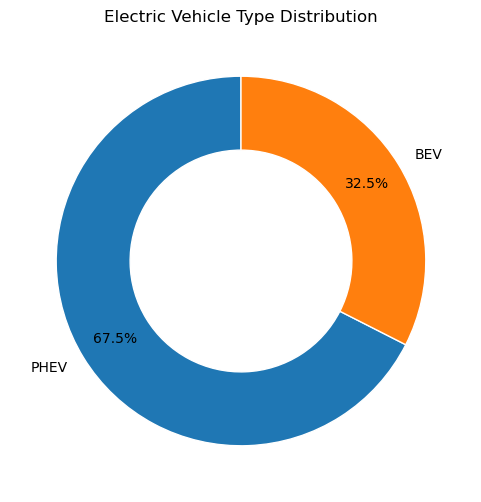

In [40]:
plt.figure(figsize=(6,6))

counts = df["electric_vehicle_type"].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'width':0.4, 'edgecolor':'white'}
)

plt.title("Electric Vehicle Type Distribution")
plt.show()

In [41]:
df.columns


Index(['state', 'model_year', 'make', 'electric_vehicle_type',
       'electric_range', 'base_msrp', 'legislative_district',
       'cafveligibility_simple', 'vehicle_age', 'range_category',
       'price_category', 'ev_category', 'generation', 'range_score',
       'make_popularity'],
      dtype='object')

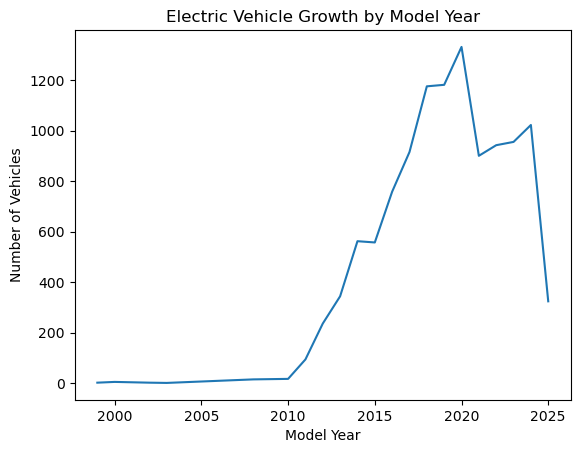

In [42]:
df["model_year"].value_counts().sort_index().plot(kind="line")

plt.title("Electric Vehicle Growth by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.show()

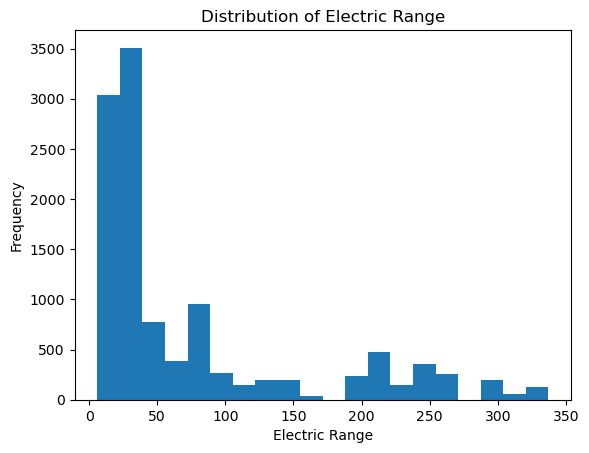

In [43]:
df["electric_range"].plot(kind="hist", bins=20)
plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range")
plt.ylabel("Frequency")
plt.show()


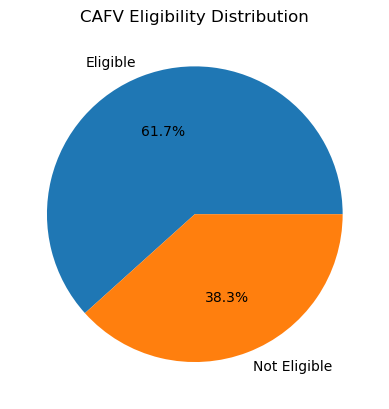

In [44]:
df["cafveligibility_simple"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("CAFV Eligibility Distribution")
plt.ylabel("")
plt.show()

In [45]:
!pip install squarify

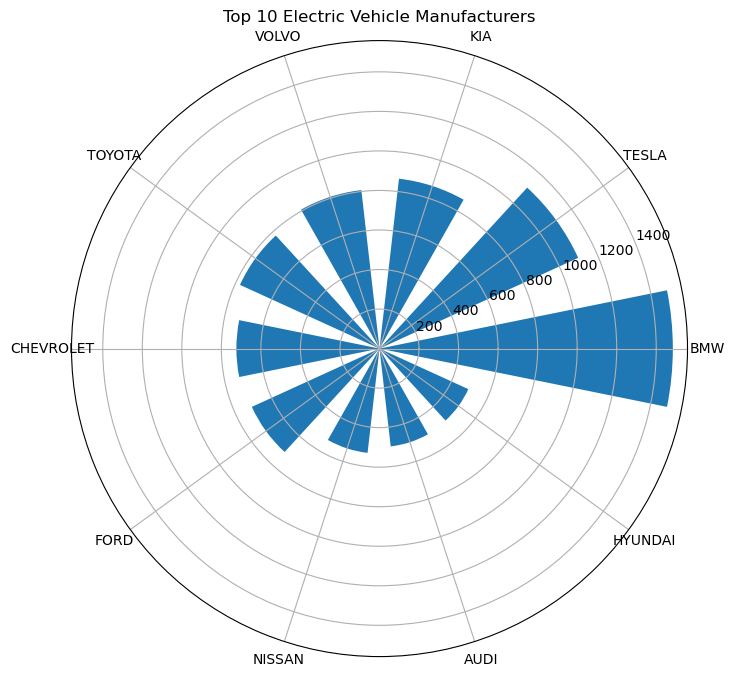

In [46]:
import numpy as np
import matplotlib.pyplot as plt

top10 = df["make"].value_counts().head(10)

angles = np.linspace(0, 2*np.pi, len(top10), endpoint=False)

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

ax.bar(angles, top10.values, width=0.4)

ax.set_xticks(angles)
ax.set_xticklabels(top10.index)

plt.title("Top 10 Electric Vehicle Manufacturers")
plt.show()

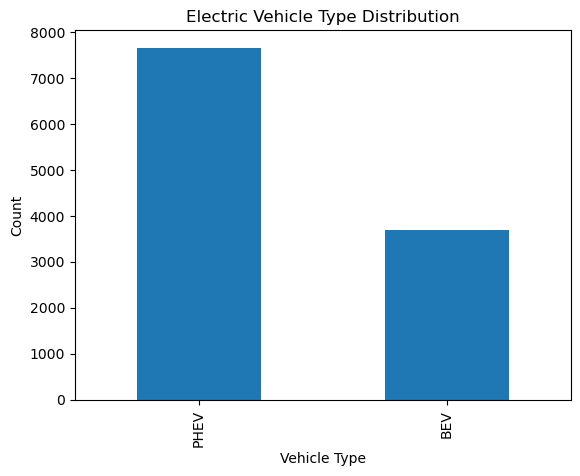

In [47]:
df["electric_vehicle_type"].value_counts().plot(kind="bar")
plt.title("Electric Vehicle Type Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.show()